In [ ]:
# Portfolio Project 1: E-commerce Sales Analytics

# This project analyzes e-commerce sales data using SQL, Python, and Tableau.

# The main goals of the project are:
# - to extract data from Google BigQuery using SQL;
# - to perform exploratory and statistical analysis in Python;
# - to build an analytical dashboard in Tableau Public.

In [ ]:
# 1.1 SETUP: GOOGLE COLAB AND BIGQUERY CONNECTION

# Authenticate user in Google Colab
from google.colab import auth
auth.authenticate_user()

# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for statistics
from scipy.stats import shapiro, pearsonr

# Import BigQuery client
from google.cloud import bigquery

# Create BigQuery client
client = bigquery.Client(project="data-analytics-mate")

# Set pandas display options to show more rows and columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Data extraction from BigQuery

Before creating the final analytical dataset, I checked the available tables and their schemas in the BigQuery dataset.

In [ ]:
# 1.2 CHECK AVAILABLE TABLES

# SQL query to get all tables from DA dataset
query = """
SELECT
  table_name
FROM `data-analytics-mate.DA.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
"""

# Execute the query
query_job = client.query(query)

# Convert the result to pandas DataFrame
tables_df = query_job.result().to_dataframe(
    create_bqstorage_client=False
)

# Display available tables
tables_df

,table_name
0,ab_test
1,account
2,account_session
3,email_open
4,email_sent
5,email_sent_view
6,email_visit
7,event_params
8,order
9,paid_search_cost


In [ ]:
# 1.3 CHECK TABLE SCHEMAS

# Create a list of tables that are needed for the analytical dataset
tables_to_check = [
    "session",
    "order",
    "account",
    "account_session",
    "product",
    "session_params"
]

# Loop through each table and display its columns and data types
for table in tables_to_check:
    print(f"\n===== {table.upper()} =====")

    # SQL query to get column names and data types for the selected table
    query = f"""
    SELECT
        column_name,
        data_type
    FROM `data-analytics-mate.DA.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = '{table}'
    ORDER BY ordinal_position
    """

    # Execute the query and convert the result to pandas DataFrame
    schema_df = client.query(query).result().to_dataframe(
        create_bqstorage_client=False
    )

    # Display table schema
    display(schema_df)


===== SESSION =====


,column_name,data_type
0,date,DATE
1,ga_session_id,INT64



===== ORDER =====


,column_name,data_type
0,ga_session_id,INT64
1,item_id,INT64



===== ACCOUNT =====


...

,column_name,data_type
0,account_id,INT64
1,ga_session_id,INT64



===== PRODUCT =====


,column_name,data_type
0,item_id,INT64
1,name,STRING
2,category,STRING
3,price,FLOAT64
4,short_description,STRING



===== SESSION_PARAMS =====


,column_name,data_type
0,ga_session_id,INT64
1,device,STRING
2,mobile_model_name,STRING
3,operating_system,STRING
4,language,STRING
5,browser,STRING
6,continent,STRING
7,country,STRING
8,medium,STRING
9,name,STRING


The checked tables contain the fields required for this project:

- `session` contains session ID and date;
- `session_params` contains geography, device, browser, language and traffic information;
- `order` connects sessions with purchased products;
- `product` contains product category, name, price and description;
- `account_session` connects sessions with registered users;
- `account` contains user verification and subscription status.

The `session` table will be used as the base table because the project requires keeping all sessions, including sessions without purchases and sessions from unregistered users.

In [ ]:
# 2.1 CREATE MAIN ANALYTICAL DATASET

# SQL query to create the main analytical dataset
query = """
SELECT
    s.date AS order_date,
    s.ga_session_id,

    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.language,
    sp.medium AS traffic_source,
    sp.channel AS traffic_channel,

    a.id AS account_id,
    a.is_verified,
    a.is_unsubscribed,

    p.category AS product_category,
    p.name AS product_name,
    p.price,
    p.short_description

FROM `data-analytics-mate.DA.session` AS s

-- Add session parameters such as geography, device and traffic information
LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
    ON s.ga_session_id = sp.ga_session_id

-- Add order information; LEFT JOIN keeps sessions without purchases
LEFT JOIN `data-analytics-mate.DA.order` AS o
    ON s.ga_session_id = o.ga_session_id

-- Add product details for purchased items
LEFT JOIN `data-analytics-mate.DA.product` AS p
    ON o.item_id = p.item_id

-- Add account-session relationship
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
    ON s.ga_session_id = acs.ga_session_id

-- Add registered user information
LEFT JOIN `data-analytics-mate.DA.account` AS a
    ON acs.account_id = a.id
"""

# Execute the query
query_job = client.query(query)

# Convert the result to pandas DataFrame
df = query_job.result().to_dataframe(
    create_bqstorage_client=False
)

# Show the first rows of the dataset
df.head()

,order_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,is_verified,is_unsubscribed,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
# 2.2 VALIDATE JOINS

# Count rows in session table
query_sessions = """
SELECT COUNT(*) AS session_rows
FROM `data-analytics-mate.DA.session`
"""

# Count rows in order table
query_orders = """
SELECT COUNT(*) AS order_rows
FROM `data-analytics-mate.DA.order`
"""

# Execute queries
session_rows = client.query(query_sessions).result().to_dataframe(
    create_bqstorage_client=False
)

order_rows = client.query(query_orders).result().to_dataframe(
    create_bqstorage_client=False
)

# Count unique sessions in final dataset
unique_sessions = df["ga_session_id"].nunique()

# Count rows containing product data
purchase_rows = df["product_name"].notna().sum()

print("Rows in session table:")
display(session_rows)

print("Rows in order table:")
display(order_rows)

print("Unique sessions in final dataset:", unique_sessions)
print("Rows with product information:", purchase_rows)

Rows in session table:


,session_rows
0,349545


Rows in order table:


,order_rows
0,33538


Unique sessions in final dataset: 349545
Rows with product information: 33538


The main analytical dataset was created using LEFT JOINs.

This join strategy allows us to keep:
- all website sessions;
- sessions without purchases;
- sessions made by unregistered users.

The `order_date` field is based on the session date. Since order data is connected to sessions, this date is used as the transaction/session date for further analysis.

# 3. Dataset overview

In this section, I describe the structure of the final dataset: number of rows and columns, data types, unique sessions, date range and missing values.

In [ ]:
# 3.1 DATASET SHAPE AND GENERAL INFORMATION

# Check dataset shape: number of rows and columns
print("Dataset shape:", df.shape)

# Check general information about columns, non-null values and data types
df.info()

Dataset shape: (349545, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_date         349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  traffic_channel    349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  product_category   33538 non-null   object 
 15  product_name       3353

In [ ]:
# 3.2 COLUMN TYPES

# Select numeric columns
numeric_cols = df.select_dtypes(include=["Int64", "float64"]).columns.tolist()

# Select categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Select datetime columns
datetime_cols = df.select_dtypes(include=["datetime64"]).columns.tolist()

# Display number and names of numeric columns
print("Number of numeric columns:", len(numeric_cols))
print("Numeric columns:", numeric_cols)

# Display number and names of categorical columns
print("\nNumber of categorical columns:", len(categorical_cols))
print("Categorical columns:", categorical_cols)

# Display number and names of datetime columns
print("\nNumber of datetime columns:", len(datetime_cols))
print("Datetime columns:", datetime_cols)

Number of numeric columns: 5
Numeric columns: ['ga_session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']

Number of categorical columns: 12
Categorical columns: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'traffic_channel', 'product_category', 'product_name', 'short_description']

Number of datetime columns: 1
Datetime columns: ['order_date']


In [ ]:
# 3.3 UNIQUE SESSIONS

# Count number of unique sessions in the final dataset
unique_sessions = df["ga_session_id"].nunique()

# Display number of unique sessions
print(f"Unique sessions: {unique_sessions:,}")

Unique sessions: 349,545


In [ ]:
# 3.4 CONVERT DATE COLUMN TO DATETIME

# Convert order_date column to datetime format for time series analysis
df["order_date"] = pd.to_datetime(df["order_date"])

# Display the analyzed time period
print("Start date:", df["order_date"].min())
print("End date:", df["order_date"].max())

Start date: 2020-11-01 00:00:00
End date: 2021-01-31 00:00:00


In [ ]:
# 3.5 MISSING VALUES

# Calculate missing values count and percentage for each column
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": round(df.isna().mean() * 100, 2)
})

# Display columns sorted by number of missing values
missing.sort_values("missing_count", ascending=False)

,missing_count,missing_percent
is_unsubscribed,321600,92.01
is_verified,321600,92.01
account_id,321600,92.01
short_description,316007,90.41
product_name,316007,90.41
product_category,316007,90.41
price,316007,90.41
language,114266,32.69
ga_session_id,0,0.00
order_date,0,0.00


The dataset contains 349,545 rows and 18 columns.

It includes:
- 5 numeric columns;
- 12 categorical columns;
- 1 datetime column.

However, not all numeric columns are business metrics.  
`ga_session_id` and `account_id` are identifiers, while `is_verified` and `is_unsubscribed` are binary user flags. The main numerical metric for sales analysis is `price`.

The dataset covers the period from 2020-11-01 to 2021-01-31.

The dataset contains 349545 unique sessions.

### Missing values explanation

Most missing values are expected and are caused by the structure of the data.

Missing values in `account_id`, `is_verified`, and `is_unsubscribed` appear because most sessions belong to users who were not registered.

Missing values in product-related columns appear because not every session resulted in a purchase.

The `language` column also contains missing values, which may happen when browser language information was not collected during the session.

In [ ]:
# 3.6 DATA VALIDATION

# SQL query to count rows in the original session table
query_sessions = """
SELECT COUNT(*) AS session_rows
FROM `data-analytics-mate.DA.session`
"""

# SQL query to count rows in the original order table
query_orders = """
SELECT COUNT(*) AS order_rows
FROM `data-analytics-mate.DA.order`
"""

# Execute session count query and convert result to DataFrame
session_rows = client.query(query_sessions).result().to_dataframe(
    create_bqstorage_client=False
)

# Execute order count query and convert result to DataFrame
order_rows = client.query(query_orders).result().to_dataframe(
    create_bqstorage_client=False
)

# Display number of rows in the original session table
print("Rows in session table:")
display(session_rows)

# Display number of rows in the original order table
print("Rows in order table:")
display(order_rows)

# Display number of unique sessions in the final dataset
print("Unique sessions in final dataset:", df["ga_session_id"].nunique())

# Count product rows in the final dataset
print("Rows with product information:", df["product_name"].notna().sum())

Rows in session table:


,session_rows
0,349545


Rows in order table:


,order_rows
0,33538


Unique sessions in final dataset: 349545
Rows with product information: 33538


The number of unique sessions in the final dataset matches the number of rows in the original `session` table. This confirms that the LEFT JOIN strategy preserved all sessions.

The number of rows with product information matches the number of rows in the original `order` table. This confirms that product data was joined correctly for purchase sessions.

In [ ]:
# 4.1 TOP CONTINENTS BY SALES

# Filter only rows with purchases and calculate total sales and number of orders by continent
continent_sales = (
    df.dropna(subset=["price"])
      .groupby("continent", as_index=False)
      .agg(
          total_sales=("price", "sum"),
          orders=("price", "count")
      )
      .sort_values("total_sales", ascending=False)
)

# Display sales by continent
continent_sales

,continent,total_sales,orders
2,Americas,17665280.0,18553
3,Asia,7601298.3,7950
4,Europe,5934624.2,6261
5,Oceania,365230.2,364
1,Africa,331231.0,339
0,(not set),74067.4,71


In [ ]:
# 4.1.1 TOP COUNTRIES BY SALES

# Filter only rows with purchases and calculate total sales and number of orders by country
country_sales = (
    df.dropna(subset=["price"])
      .groupby("country", as_index=False)
      .agg(
          total_sales=("price", "sum"),
          orders=("price", "count")
      )
      .sort_values("total_sales", ascending=False)
)

# Display top countries by sales
country_sales.head(10)

,country,total_sales,orders
104,United States,13943553.9,14673
43,India,2809762.0,3029
18,Canada,2437921.0,2560
103,United Kingdom,938317.9,1029
33,France,710692.8,678
92,Spain,631546.7,658
35,Germany,599221.4,642
20,China,588329.6,600
96,Taiwan,552710.3,564
87,Singapore,456447.2,454


In [ ]:
# 4.1.3 Top 3 continents by number of orders

top3_continents_orders = (
    continent_sales
    .sort_values("orders", ascending=False)
    .head(3)
)

top3_continents_orders

,continent,total_sales,orders
2,Americas,17665280.0,18553
3,Asia,7601298.3,7950
4,Europe,5934624.2,6261


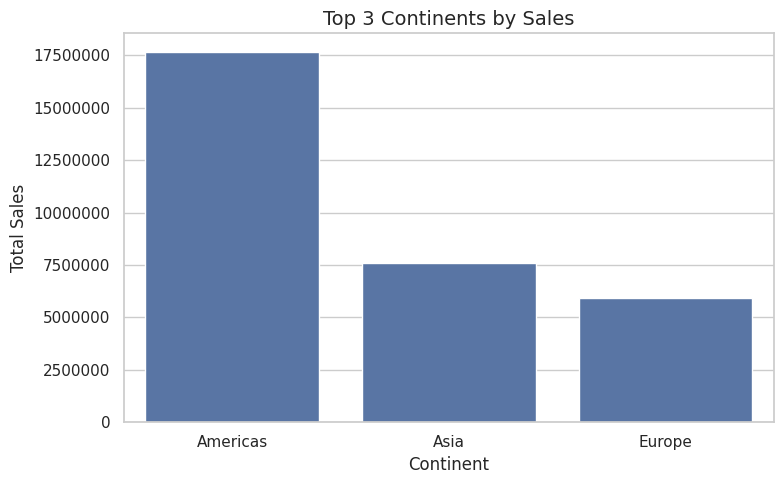

In [ ]:
# 4.1.2 VISUALIZATION: TOP 3 CONTINENTS BY SALES

# Select top 3 continents by total sales
top3_continents = (
    continent_sales
    .nlargest(3, "total_sales")
    .copy()
)

plt.figure(figsize=(8, 5))

# Create bar chart
sns.barplot(
    data=top3_continents,
    x="continent",
    y="total_sales"
)

plt.title("Top 3 Continents by Sales", fontsize=14)
plt.xlabel("Continent")
plt.ylabel("Total Sales")

plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# 4.1.4 Top 5 countries by number of orders

top5_countries_orders = (
    country_sales
    .sort_values("orders", ascending=False)
    .head(5)
)

top5_countries_orders

,country,total_sales,orders
104,United States,13943553.9,14673
43,India,2809762.0,3029
18,Canada,2437921.0,2560
103,United Kingdom,938317.9,1029
33,France,710692.8,678


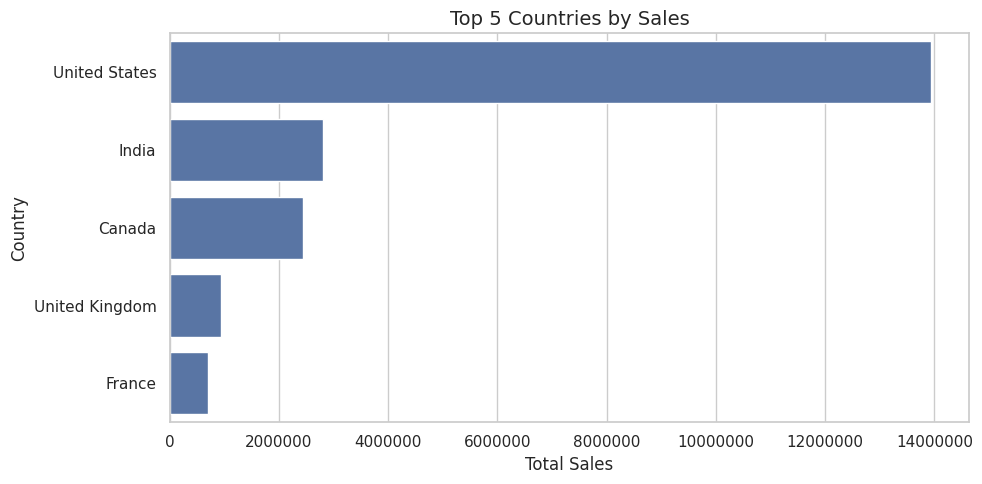

In [ ]:
# 4.1.3 VISUALIZATION: TOP 5 COUNTRIES BY SALES

# Select top 5 countries by total sales
top5_countries = (
    country_sales
    .nlargest(5, "total_sales")
    .copy()
)

plt.figure(figsize=(10, 5))

# Create horizontal bar chart
sns.barplot(
    data=top5_countries,
    x="total_sales",
    y="country"
)

plt.title("Top 5 Countries by Sales", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("Country")

plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

The Americas is the leading continent both by total sales and by number of orders.  
At the country level, the United States strongly dominates sales, followed by India and Canada.

This indicates that the company's revenue is highly concentrated in the American market, especially in the United States.

In [ ]:
# 4.2 TOP PRODUCT CATEGORIES BY SALES

# Calculate total sales and number of orders by product category
category_sales = (
    df.dropna(subset=["price"])
      .groupby("product_category", as_index=False)
      .agg(
          total_sales=("price", "sum"),
          orders=("price", "count")
      )
      .sort_values("total_sales", ascending=False)
)

# Display top categories
category_sales.head(10)

,product_category,total_sales,orders
12,Sofas & armchairs,8388254.5,4301
5,Chairs,6147748.8,5952
1,Beds,4919725.0,2926
2,Bookcases & shelving units,3640818.1,7630
3,Cabinets & cupboards,2336499.5,2318
9,Outdoor furniture,2142222.2,2229
13,Tables & desks,1790307.5,2941
6,Chests of drawers & drawer units,906562.5,1452
0,Bar furniture,735503.0,1092
7,Children's furniture,467697.0,1702


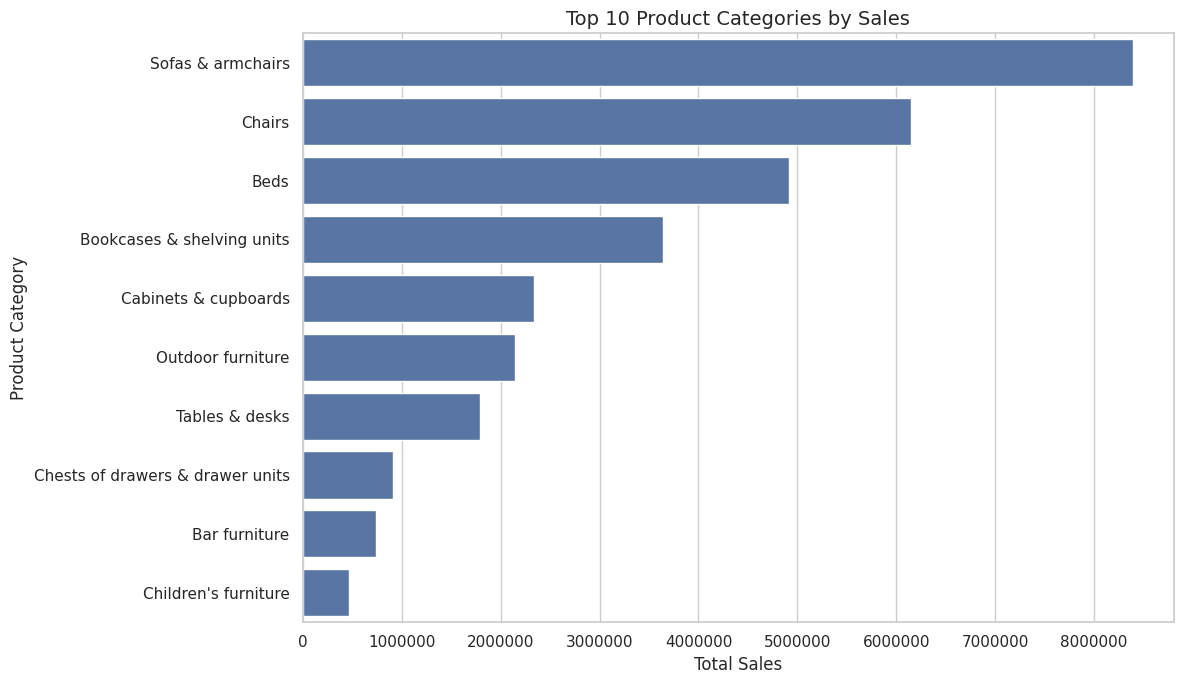

In [ ]:
# 4.2.1 VISUALIZATION: TOP 10 PRODUCT CATEGORIES

# Select top 10 product categories
top10_categories = category_sales.head(10).copy()

plt.figure(figsize=(12, 7))

# Create horizontal bar chart
sns.barplot(
    data=top10_categories,
    x="total_sales",
    y="product_category"
)

plt.title("Top 10 Product Categories by Sales", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate average order value for each product category
category_sales["avg_order_value"] = (
    category_sales["total_sales"] /
    category_sales["orders"]
).round(2)

# Display category statistics
category_sales.head(10)

,product_category,total_sales,orders,avg_order_value
12,Sofas & armchairs,8388254.5,4301,1950.30
5,Chairs,6147748.8,5952,1032.89
1,Beds,4919725.0,2926,1681.38
2,Bookcases & shelving units,3640818.1,7630,477.17
3,Cabinets & cupboards,2336499.5,2318,1007.98
9,Outdoor furniture,2142222.2,2229,961.07
13,Tables & desks,1790307.5,2941,608.74
6,Chests of drawers & drawer units,906562.5,1452,624.35
0,Bar furniture,735503.0,1092,673.54
7,Children's furniture,467697.0,1702,274.79


Sofas & armchairs is the leading product category by total sales, followed by Chairs and Beds.

Bookcases & shelving units have the highest number of orders among top categories, but a lower average order value, which explains their lower revenue compared to premium furniture categories.

In [ ]:
# 4.3 TOP CATEGORIES IN TOP COUNTRY

# Filter United States sales and calculate category statistics
us_category_sales = (
    df[
        (df["country"] == "United States") &
        (df["price"].notna())
    ]
    .groupby("product_category", as_index=False)
    .agg(
        total_sales=("price", "sum"),
        orders=("price", "count")
    )
    .sort_values("total_sales", ascending=False)
)

# Display top categories in United States
us_category_sales.head(10)

,product_category,total_sales,orders
12,Sofas & armchairs,3707144.5,1903
5,Chairs,2619773.8,2576
1,Beds,2213058.0,1298
2,Bookcases & shelving units,1567606.9,3374
3,Cabinets & cupboards,994545.5,995
9,Outdoor furniture,929245.2,984
13,Tables & desks,777865.0,1248
6,Chests of drawers & drawer units,382388.0,616
0,Bar furniture,330805.0,487
7,Children's furniture,207575.0,752


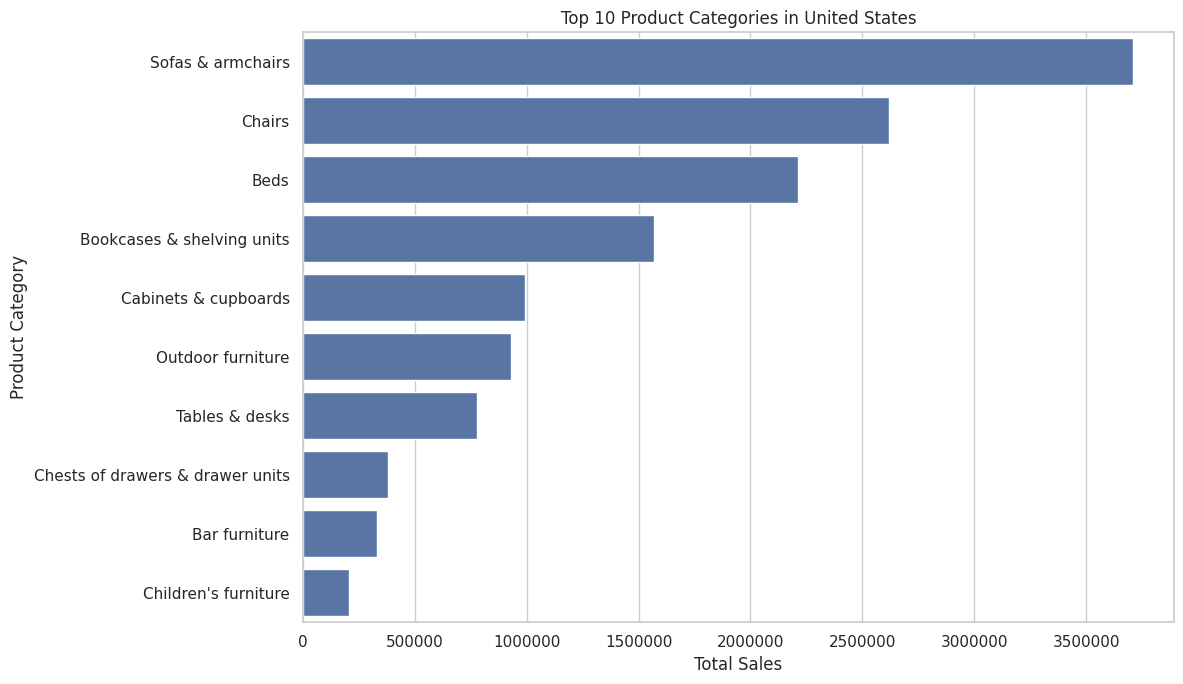

In [ ]:
# 4.3.1 VISUALIZATION: TOP 10 PRODUCT CATEGORIES IN UNITED STATES

# Select top 10 US categories
top10_us = us_category_sales.head(10)

plt.figure(figsize=(12, 7))

# Create horizontal bar chart
sns.barplot(
    data=top10_us,
    x="total_sales",
    y="product_category"
)

plt.title("Top 10 Product Categories in United States")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Compare global category sales shares
global_top10 = category_sales.head(10).copy()

global_top10["sales_share_pct"] = (
    global_top10["total_sales"] /
    global_top10["total_sales"].sum() * 100
).round(2)

global_top10

,product_category,total_sales,orders,avg_order_value,sales_share_pct
12,Sofas & armchairs,8388254.5,4301,1950.30,26.65
5,Chairs,6147748.8,5952,1032.89,19.53
1,Beds,4919725.0,2926,1681.38,15.63
2,Bookcases & shelving units,3640818.1,7630,477.17,11.57
3,Cabinets & cupboards,2336499.5,2318,1007.98,7.42
9,Outdoor furniture,2142222.2,2229,961.07,6.81
13,Tables & desks,1790307.5,2941,608.74,5.69
6,Chests of drawers & drawer units,906562.5,1452,624.35,2.88
0,Bar furniture,735503.0,1092,673.54,2.34
7,Children's furniture,467697.0,1702,274.79,1.49


In [ ]:
# Compare United States category sales shares
us_top10 = us_category_sales.head(10).copy()

us_top10["sales_share_pct"] = (
    us_top10["total_sales"] /
    us_top10["total_sales"].sum() * 100
).round(2)

us_top10

,product_category,total_sales,orders,sales_share_pct
12,Sofas & armchairs,3707144.5,1903,27.00
5,Chairs,2619773.8,2576,19.08
1,Beds,2213058.0,1298,16.12
2,Bookcases & shelving units,1567606.9,3374,11.42
3,Cabinets & cupboards,994545.5,995,7.24
9,Outdoor furniture,929245.2,984,6.77
13,Tables & desks,777865.0,1248,5.67
6,Chests of drawers & drawer units,382388.0,616,2.79
0,Bar furniture,330805.0,487,2.41
7,Children's furniture,207575.0,752,1.51


The product category structure in the United States is highly similar to the global sales structure.

The same product categories dominate both globally and in the United States, indicating a consistent purchasing pattern across the largest market.

In [ ]:
# 4.4 SALES BY DEVICE TYPE

# Calculate total sales by device type
device_sales = (
    df.dropna(subset=["price"])
      .groupby("device", as_index=False)
      .agg(total_sales=("price", "sum"))
)

# Calculate percentage share of total sales
device_sales["sales_share_pct"] = (
    device_sales["total_sales"] /
    device_sales["total_sales"].sum() * 100
).round(2)

# Display device sales
device_sales.sort_values("sales_share_pct", ascending=False)

,device,total_sales,sales_share_pct
0,desktop,18864039.0,59.00
1,mobile,12384225.8,38.73
2,tablet,723466.3,2.26


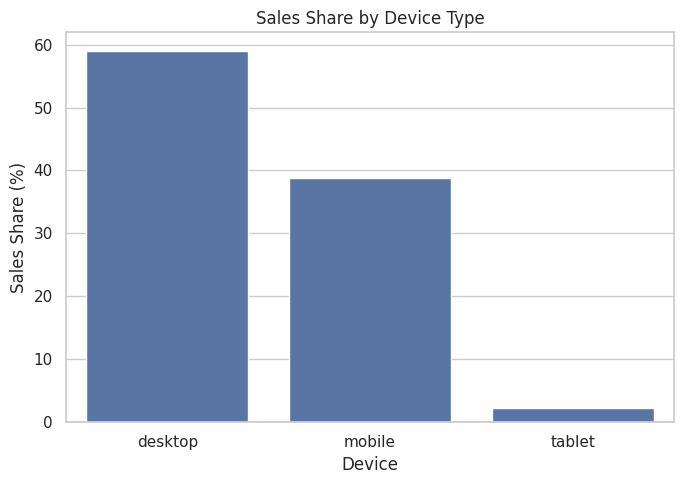

In [ ]:
# 4.4.1 VISUALIZATION: SALES SHARE BY DEVICE TYPE

plt.figure(figsize=(7, 5))

# Create bar chart
sns.barplot(
    data=device_sales.sort_values("sales_share_pct", ascending=False),
    x="device",
    y="sales_share_pct"
)

plt.title("Sales Share by Device Type")
plt.xlabel("Device")
plt.ylabel("Sales Share (%)")

plt.tight_layout()
plt.show()

Desktop devices generate the highest share of total sales, followed by mobile devices.

This suggests that users are more likely to complete purchases on larger screens, while tablet devices contribute only a small share of revenue.

In [ ]:
# 4.5 SALES BY TRAFFIC CHANNEL

# Calculate total sales by traffic channel
traffic_sales = (
    df.dropna(subset=["price"])
      .groupby("traffic_channel", as_index=False)
      .agg(
          total_sales=("price", "sum")
      )
)

# Calculate percentage share
traffic_sales["sales_share_pct"] = (
    traffic_sales["total_sales"] /
    traffic_sales["total_sales"].sum() * 100
).round(2)

# Sort channels by sales share
traffic_sales = traffic_sales.sort_values(
    "sales_share_pct",
    ascending=False
)

# Display traffic sales
traffic_sales

,traffic_channel,total_sales,sales_share_pct
1,Organic Search,11433151.6,35.76
2,Paid Search,8511049.4,26.62
0,Direct,7494923.4,23.44
3,Social Search,2532105.7,7.92
4,Undefined,2000501.0,6.26


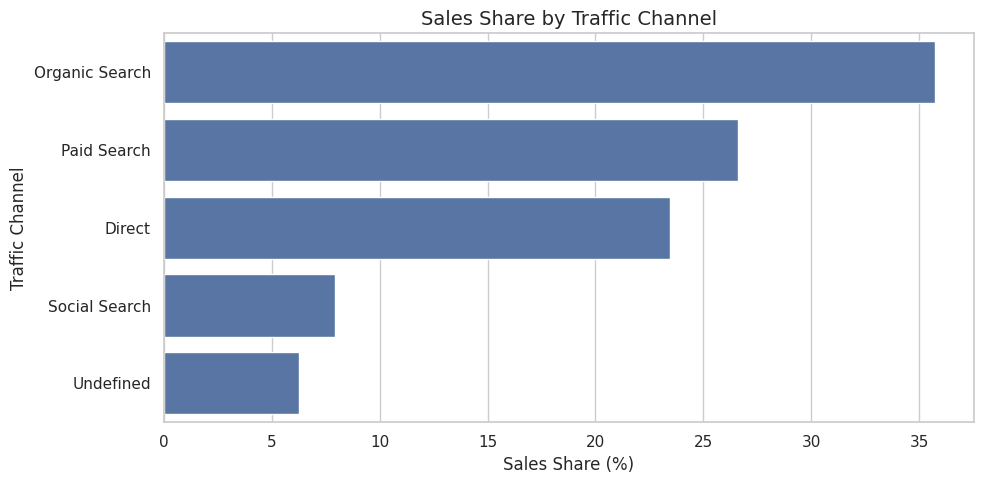

In [ ]:
# 4.5.1 VISUALIZATION: SALES SHARE BY TRAFFIC CHANNEL

plt.figure(figsize=(10, 5))

# Create horizontal bar chart
sns.barplot(
    data=traffic_sales,
    x="sales_share_pct",
    y="traffic_channel"
)

plt.title("Sales Share by Traffic Channel", fontsize=14)
plt.xlabel("Sales Share (%)")
plt.ylabel("Traffic Channel")

plt.tight_layout()
plt.show()

Organic Search generates the largest share of sales, followed by Paid Search and Direct traffic.

Search-driven channels contribute the majority of revenue, indicating that customer acquisition through search plays a key role in sales performance.

In [ ]:
# 4.6 REGISTERED USERS ANALYSIS

# Select only registered users and keep one row per account
registered_users = (
    df[df["account_id"].notna()]
    [["account_id", "is_verified", "is_unsubscribed"]]
    .drop_duplicates()
)

# Display first rows
registered_users.head()

,account_id,is_verified,is_unsubscribed
28,649280,1,1
50,676055,1,1
58,677981,0,0
80,672927,1,0
96,653089,1,0


In [ ]:
# 4.6.1 VERIFIED AND UNSUBSCRIBED USERS SHARE

# Count total registered users
total_registered = registered_users["account_id"].nunique()
print(f"Total registered users: {total_registered}")

# Calculate percentage of users who verified their email
verified_pct = (
    registered_users["is_verified"].mean() * 100
).round(2)

print(f"Verified users: {verified_pct}%")

# Calculate percentage of users who unsubscribed from email marketing
unsubscribed_pct = (
    registered_users["is_unsubscribed"].mean() * 100
).round(2)

print(f"Unsubscribed users: {unsubscribed_pct}%")

Total registered users: 27945
Verified users: 71.7%
Unsubscribed users: 16.94%


71.7% of registered users verified their email address.

16.94% of registered users unsubscribed from the mailing list. This means that most registered users still remain subscribed to email communication.

In [ ]:
# 4.7 SUBSCRIBED VS UNSUBSCRIBED USERS

# Calculate total sales and orders for each registered user
user_sales = (
    df[df["account_id"].notna()]
    .groupby(
        ["account_id", "is_unsubscribed"],
        as_index=False
    )
    .agg(
        total_sales=("price", "sum"),
        total_orders=("price", "count")
    )
)

# Display first rows
user_sales.head()

,account_id,is_unsubscribed,total_sales,total_orders
0,636133,1,0.0,0
1,636135,1,0.0,0
2,636136,1,0.0,0
3,636138,0,395.0,1
4,636139,0,125.0,1


In [ ]:
# 4.7.1 COMPARE SUBSCRIBED AND UNSUBSCRIBED USERS

# Compare average sales and orders by subscription status
subscription_comparison = (
    user_sales
    .groupby("is_unsubscribed", as_index=False)
    .agg(
        avg_sales=("total_sales", "mean"),
        avg_orders=("total_orders", "mean"),
        users=("account_id", "count")
    )
)

# Display comparison
subscription_comparison

,is_unsubscribed,avg_sales,avg_orders,users
0,0,92.666820,0.100560,23210
1,1,91.176684,0.094403,4735


Subscribed and unsubscribed users show very similar average sales and average number of orders.

Subscribed users have slightly higher average sales and order frequency, but the difference is small at this descriptive analysis stage.

In [ ]:
# 4.8 REGISTERED USERS BY COUNTRY

# Count registered users by country
registered_by_country = (
    df[df["account_id"].notna()]
    [["country", "account_id"]]
    .drop_duplicates()
    .groupby("country", as_index=False)
    .agg(
        registered_users=("account_id", "count")
    )
    .sort_values("registered_users", ascending=False)
)

# Display top countries by registered users
registered_by_country.head(10)

,country,registered_users
104,United States,12384
43,India,2687
18,Canada,2067
103,United Kingdom,859
33,France,553
92,Spain,536
96,Taiwan,500
20,China,490
35,Germany,490
48,Italy,386


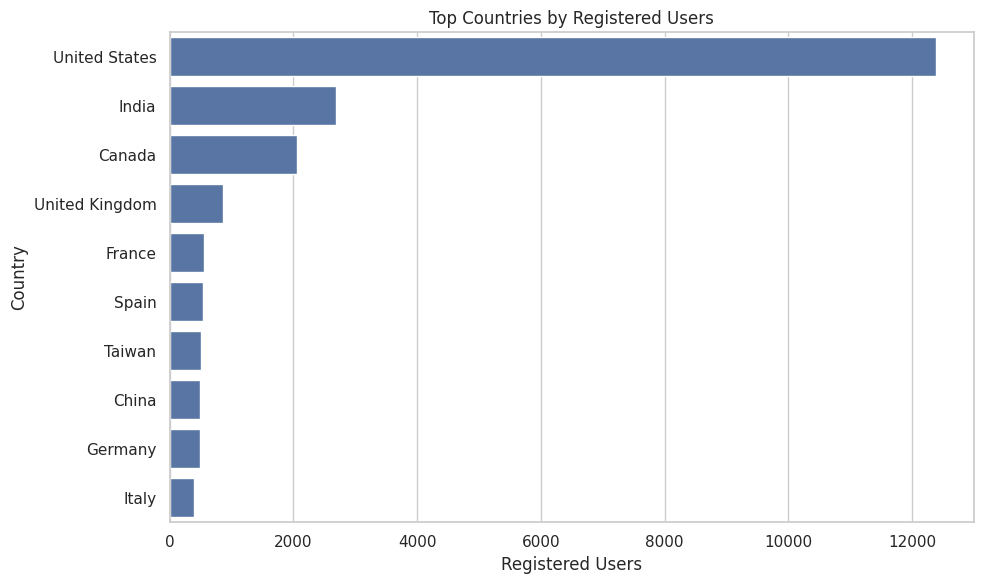

In [ ]:
# 4.8.1 VISUALIZATION: TOP COUNTRIES BY REGISTERED USERS

# Select top 10 countries by number of registered users
top10_registered = registered_by_country.head(10)

plt.figure(figsize=(10, 6))

# Create horizontal bar chart
sns.barplot(
    data=top10_registered,
    x="registered_users",
    y="country"
)

plt.title("Top Countries by Registered Users")
plt.xlabel("Registered Users")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

The United States has the highest number of registered users, followed by India and Canada.

This pattern is consistent with the sales distribution, where the United States is also the leading country by total sales.

## 5. Sales dynamics

This section analyzes sales trends over time by date, continent, traffic channel and device type.

In [ ]:
# 5.1 DAILY SALES DYNAMICS

# Calculate total sales and number of orders for each date
daily_sales = (
    df.dropna(subset=["price"])
    .groupby("order_date", as_index=False)
    .agg(
        total_sales=("price", "sum"),
        total_orders=("price", "count")
    )
)

# Display first rows
daily_sales.head()

,order_date,total_sales,total_orders
0,2020-11-01,244292.5,281
1,2020-11-02,355506.8,368
2,2020-11-03,498979.6,561
3,2020-11-04,339187.1,370
4,2020-11-05,391276.6,388


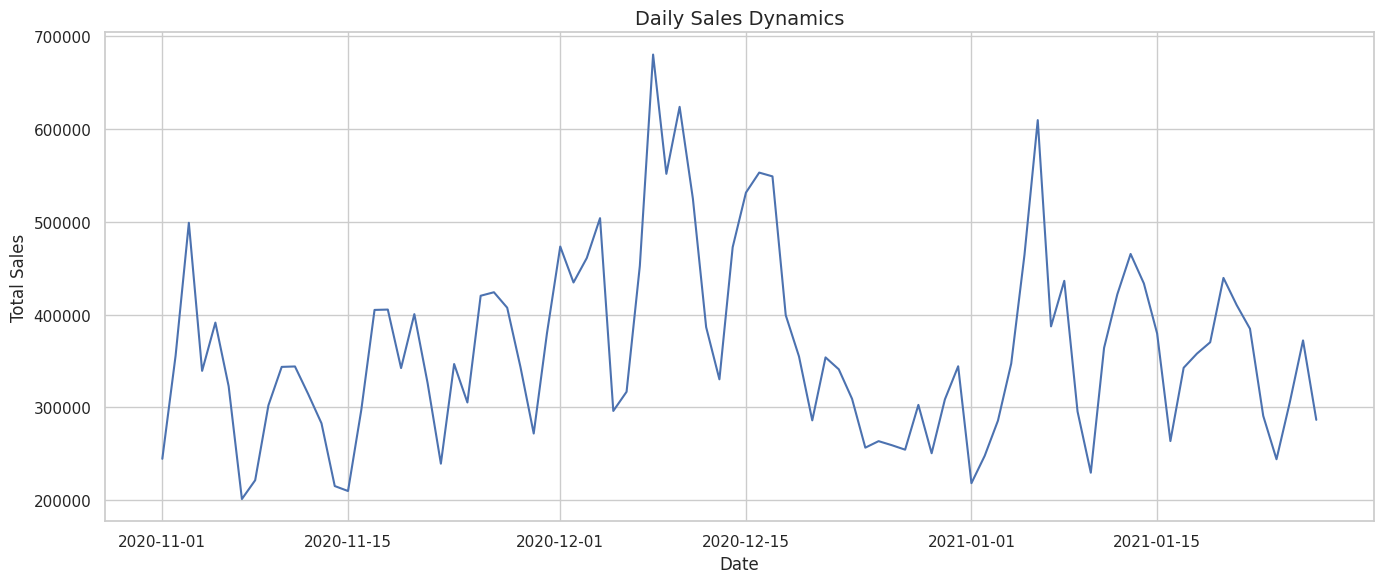

In [ ]:
# 5.1.1 VISUALIZATION: DAILY SALES DYNAMICS

plt.figure(figsize=(14, 6))

# Create line chart for daily sales
sns.lineplot(
    data=daily_sales,
    x="order_date",
    y="total_sales"
)

plt.title("Daily Sales Dynamics", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

Daily sales fluctuate during the analyzed period, with several visible peaks in December and early January.

The dataset covers only three months, so strong seasonality cannot be confirmed reliably. However, short-term sales spikes are clearly visible.

In [ ]:
# 5.2 SALES DYNAMICS BY CONTINENT

# Define top continents for comparison
top_continents = ["Americas", "Asia", "Europe"]

# Calculate daily sales for top continents
continent_daily_sales = (
    df[
        (df["continent"].isin(top_continents)) &
        (df["price"].notna())
    ]
    .groupby(["order_date", "continent"], as_index=False)
    .agg(
        total_sales=("price", "sum")
    )
)

# Display first rows
continent_daily_sales.head()

,order_date,continent,total_sales
0,2020-11-01,Americas,132002.5
1,2020-11-01,Asia,63823.0
2,2020-11-01,Europe,46908.0
3,2020-11-02,Americas,193861.0
4,2020-11-02,Asia,79370.0


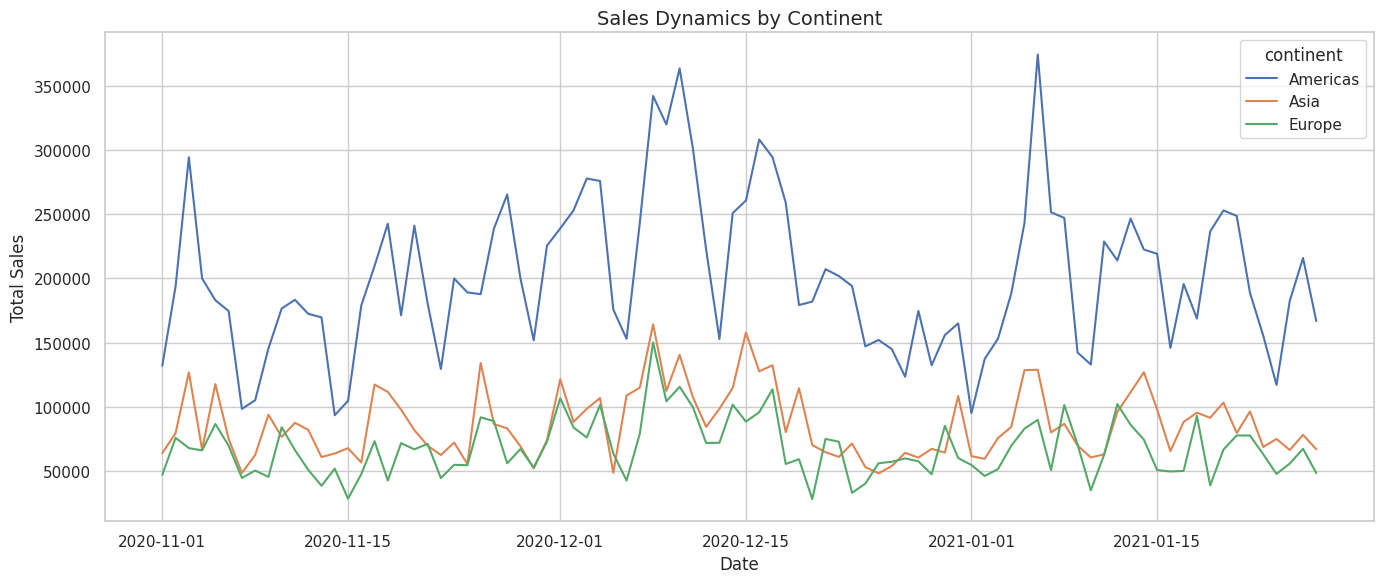

In [ ]:
# 5.2.1 VISUALIZATION: SALES DYNAMICS BY CONTINENT

plt.figure(figsize=(14, 6))

# Create line chart by continent
sns.lineplot(
    data=continent_daily_sales,
    x="order_date",
    y="total_sales",
    hue="continent"
)

plt.title("Sales Dynamics by Continent", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

The Americas consistently generate the highest daily sales during the analyzed period.

Asia and Europe show similar sales dynamics, but both remain significantly below the Americas.

In [ ]:
# 5.3 SALES DYNAMICS BY TRAFFIC CHANNEL

# Define top traffic channels for comparison
top_channels = [
    "Organic Search",
    "Paid Search",
    "Direct"
]

# Calculate daily sales by traffic channel
traffic_daily_sales = (
    df[
        (df["traffic_channel"].isin(top_channels)) &
        (df["price"].notna())
    ]
    .groupby(["order_date", "traffic_channel"], as_index=False)
    .agg(
        total_sales=("price", "sum")
    )
)

# Display first rows
traffic_daily_sales.head()

,order_date,traffic_channel,total_sales
0,2020-11-01,Direct,54669.5
1,2020-11-01,Organic Search,95112.0
2,2020-11-01,Paid Search,64688.0
3,2020-11-02,Direct,81561.5
4,2020-11-02,Organic Search,127746.5


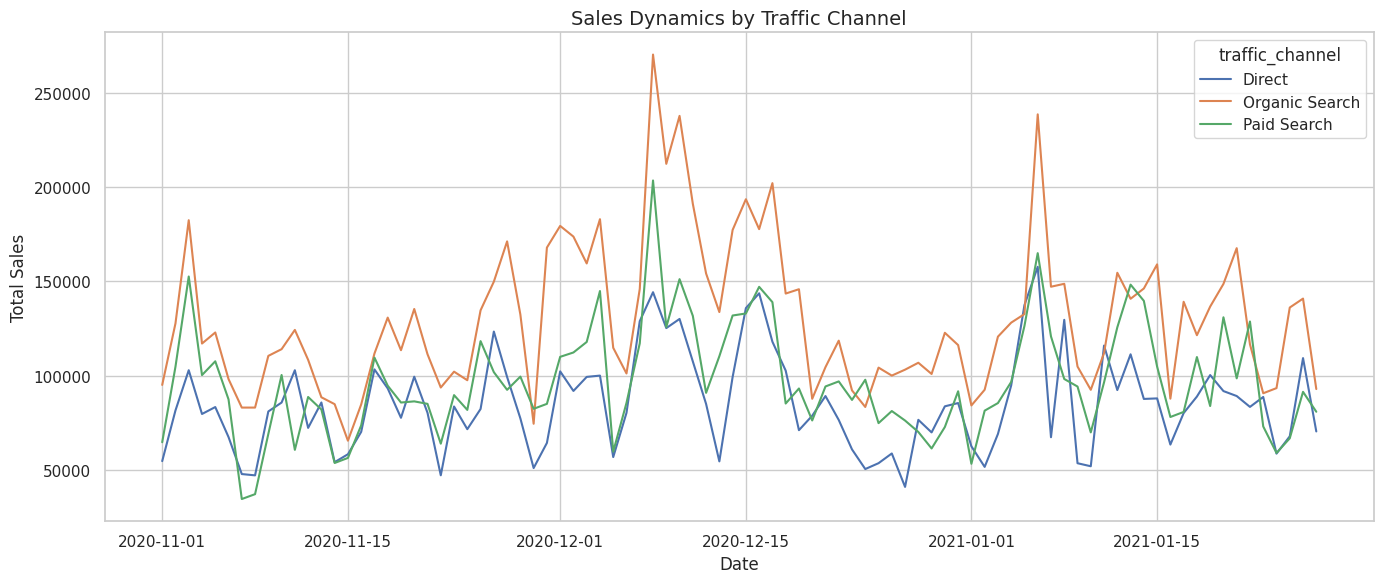

In [ ]:
# 5.3.1 VISUALIZATION: SALES DYNAMICS BY TRAFFIC CHANNEL

plt.figure(figsize=(14, 6))

# Create line chart by traffic channel
sns.lineplot(
    data=traffic_daily_sales,
    x="order_date",
    y="total_sales",
    hue="traffic_channel"
)

plt.title("Sales Dynamics by Traffic Channel", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

Organic Search is usually the strongest traffic channel by daily sales.

Paid Search and Direct traffic also contribute significantly, but Organic Search shows the highest peaks during the analyzed period.

In [ ]:
# 5.4 SALES DYNAMICS BY DEVICE TYPE

# Calculate daily sales by device type
device_daily_sales = (
    df[df["price"].notna()]
    .groupby(["order_date", "device"], as_index=False)
    .agg(
        total_sales=("price", "sum")
    )
)

# Display first rows
device_daily_sales.head()

,order_date,device,total_sales
0,2020-11-01,desktop,144445.0
1,2020-11-01,mobile,99698.5
2,2020-11-01,tablet,149.0
3,2020-11-02,desktop,206727.3
4,2020-11-02,mobile,137269.5


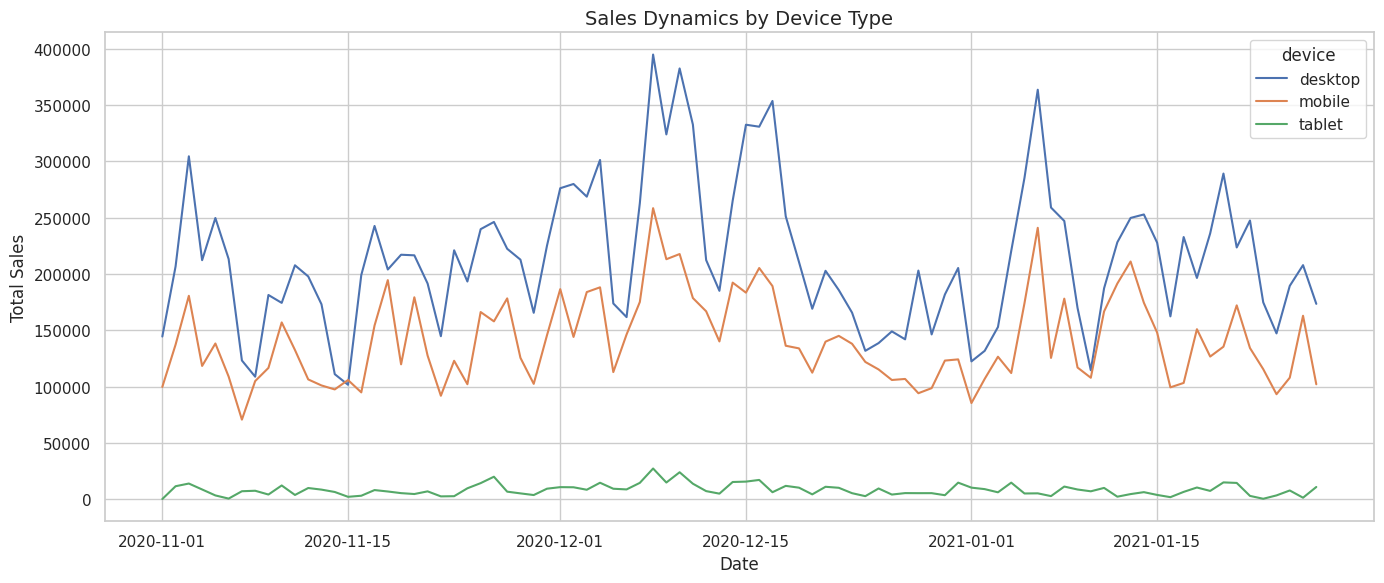

In [ ]:
# 5.4.1 VISUALIZATION: SALES DYNAMICS BY DEVICE TYPE

plt.figure(figsize=(14, 6))

# Create line chart by device type
sns.lineplot(
    data=device_daily_sales,
    x="order_date",
    y="total_sales",
    hue="device"
)

plt.title("Sales Dynamics by Device Type", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

Desktop sales are consistently higher than mobile sales across the analyzed period.

Mobile sales follow a similar pattern but remain lower, while tablet sales contribute only a very small part of total daily revenue.

In [ ]:
# 6.1 PIVOT TABLE: SESSIONS BY TRAFFIC CHANNEL AND DEVICE

# Create pivot table with number of unique sessions by traffic channel and device type
pivot_sessions = pd.pivot_table(
    df,
    values="ga_session_id",
    index="traffic_channel",
    columns="device",
    aggfunc=pd.Series.nunique
)

# Display pivot table
pivot_sessions

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [ ]:
# 6.2 PIVOT TABLE: SALES BY TOP PRODUCT CATEGORIES AND TOP COUNTRIES

# Define top 5 countries by sales
top5_countries = [
    "United States",
    "India",
    "Canada",
    "United Kingdom",
    "France"
]

# Define top 10 product categories by sales
top10_categories = category_sales.head(10)["product_category"].tolist()

# Create pivot table with total sales by product category and country
pivot_sales = pd.pivot_table(
    df[
        (df["country"].isin(top5_countries)) &
        (df["product_category"].isin(top10_categories))
    ],
    values="price",
    index="product_category",
    columns="country",
    aggfunc="sum"
)

# Display pivot table
pivot_sales

country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


In [ ]:
# 6.3 PIVOT TABLE: SALES BY TRAFFIC CHANNEL AND DEVICE

# Create pivot table with total sales by traffic channel and device type
pivot_sales_channel_device = pd.pivot_table(
    df[df["price"].notna()],
    values="price",
    index="traffic_channel",
    columns="device",
    aggfunc="sum"
)

# Display pivot table
pivot_sales_channel_device

device,desktop,mobile,tablet
traffic_channel,,,
Direct,4472609.4,2875317.9,146996.1
Organic Search,6794107.8,4408875.1,230168.7
Paid Search,4976977.8,3330032.6,204039.0
Social Search,1447384.8,1006707.3,78013.6
Undefined,1172959.2,763292.9,64248.9


In [ ]:
# 6.4 PIVOT TABLE: ORDERS BY TOP PRODUCT CATEGORIES AND DEVICE

# Define top 10 product categories by sales
top10_categories = category_sales.head(10)["product_category"].tolist()

# Create pivot table with number of orders by product category and device type
pivot_orders_category_device = pd.pivot_table(
    df[
        (df["product_category"].isin(top10_categories)) &
        (df["price"].notna())
    ],
    values="ga_session_id",
    index="product_category",
    columns="device",
    aggfunc="count"
)

# Display pivot table
pivot_orders_category_device

device,desktop,mobile,tablet
product_category,,,
Bar furniture,646,420,26
Beds,1677,1190,59
Bookcases & shelving units,4437,3035,158
Cabinets & cupboards,1379,888,51
Chairs,3528,2287,137
Chests of drawers & drawer units,857,568,27
Children's furniture,1026,644,32
Outdoor furniture,1302,881,46
Sofas & armchairs,2520,1684,97


Pivot tables show that desktop devices generate the highest number of sessions and sales across all major traffic channels.

The United States dominates sales across all top product categories, which is consistent with previous findings.

In [ ]:
# 7.1 DAILY SESSIONS VS DAILY SALES

# Calculate daily number of sessions and daily sales
daily_sessions_sales = (
    df.groupby("order_date")
      .agg(
          total_sessions=("ga_session_id", "nunique"),
          total_sales=("price", "sum")
      )
      .reset_index()
)

# Display first rows
daily_sessions_sales.head()

,order_date,total_sessions,total_sales
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


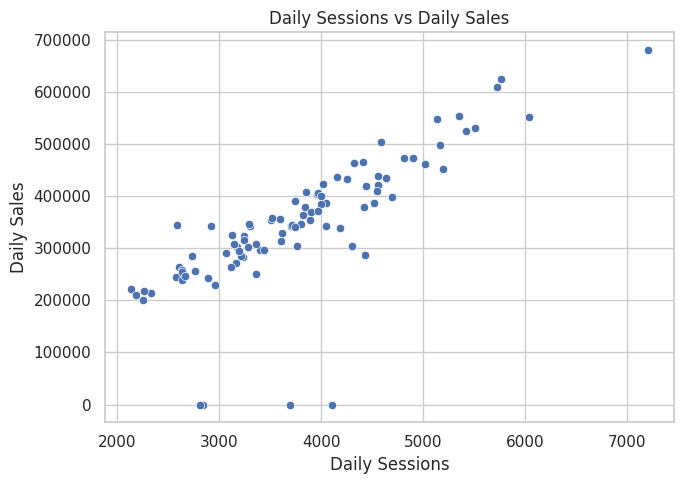

In [ ]:
# 7.1.1 VISUALIZATION: DAILY SESSIONS VS DAILY SALES

plt.figure(figsize=(7, 5))

# Create scatter plot
sns.scatterplot(
    data=daily_sessions_sales,
    x="total_sessions",
    y="total_sales"
)

plt.title("Daily Sessions vs Daily Sales")
plt.xlabel("Daily Sessions")
plt.ylabel("Daily Sales")

plt.tight_layout()
plt.show()

In [ ]:
# 7.1.2 PEARSON CORRELATION: DAILY SESSIONS VS DAILY SALES

# Calculate Pearson correlation coefficient and p-value
corr_coef, p_value = pearsonr(
    daily_sessions_sales["total_sessions"],
    daily_sessions_sales["total_sales"]
)

# Display correlation results
print(f"Correlation coefficient: {round(corr_coef, 4):.4f}")
print(f"P-value: {p_value}")

Correlation coefficient: 0.7911
P-value: 6.483532312080735e-21


Daily sessions and daily sales have a strong positive correlation.

The correlation coefficient is 0.7911, and the p-value is far below 0.05, which means the relationship is statistically significant.

In [ ]:
# 7.2 CORRELATION BETWEEN TOP CONTINENTS

# Convert daily continent sales to wide format
continent_sales_wide = (
    continent_daily_sales
    .pivot(
        index="order_date",
        columns="continent",
        values="total_sales"
    )
)

# Display first rows
continent_sales_wide.head()

continent,Americas,Asia,Europe
order_date,,,
2020-11-01,132002.5,63823.0,46908.0
2020-11-02,193861.0,79370.0,75710.8
2020-11-03,294529.8,126737.8,67692.0
2020-11-04,200009.5,66602.0,65915.0
2020-11-05,182988.2,117608.4,86540.0


In [ ]:
# Calculate correlation matrix between continents
continent_corr = continent_sales_wide.corr()

# Remove technical axis names for cleaner output
continent_corr.index.name = None
continent_corr.columns.name = None

# Display correlation matrix
continent_corr

,Americas,Asia,Europe
Americas,1.000000,0.692273,0.669527
Asia,0.692273,1.000000,0.667786
Europe,0.669527,0.667786,1.000000


In [ ]:
# Calculate Pearson correlation and p-value for each pair of continents
pairs = [
    ("Americas", "Asia"),
    ("Americas", "Europe"),
    ("Asia", "Europe")
]

for c1, c2 in pairs:
    corr, p = pearsonr(
        continent_sales_wide[c1],
        continent_sales_wide[c2]
    )

    print(f"{c1} vs {c2}")
    print(f"Correlation: {corr:.4f}")
    print(f"P-value: {p:.6f}")
    print("-" * 30)

Americas vs Asia
Correlation: 0.6923
P-value: 0.000000
------------------------------
Americas vs Europe
Correlation: 0.6695
P-value: 0.000000
------------------------------
Asia vs Europe
Correlation: 0.6678
P-value: 0.000000
------------------------------


Sales between the top three continents are positively correlated.

All tested continent pairs show statistically significant correlations, which means that sales tend to move in the same direction across regions.

In [ ]:
# 7.3 CORRELATION BETWEEN TRAFFIC CHANNELS

# Convert daily traffic channel sales to wide format
traffic_sales_wide = (
    traffic_daily_sales
    .pivot(
        index="order_date",
        columns="traffic_channel",
        values="total_sales"
    )
)

# Display first rows
traffic_sales_wide.head()

traffic_channel,Direct,Organic Search,Paid Search
order_date,,,
2020-11-01,54669.5,95112.0,64688.0
2020-11-02,81561.5,127746.5,104780.8
2020-11-03,102909.5,182521.9,152641.3
2020-11-04,79683.6,117067.1,100332.0
2020-11-05,83367.6,122938.4,107648.0


In [ ]:
# Calculate correlation matrix between traffic channels
traffic_corr = traffic_sales_wide.corr()

# Remove technical axis names to avoid labels with underscores on the heatmap
traffic_corr.index.name = None
traffic_corr.columns.name = None

# Display correlation matrix
traffic_corr

,Direct,Organic Search,Paid Search
Direct,1.000000,0.759938,0.724343
Organic Search,0.759938,1.000000,0.808234
Paid Search,0.724343,0.808234,1.000000


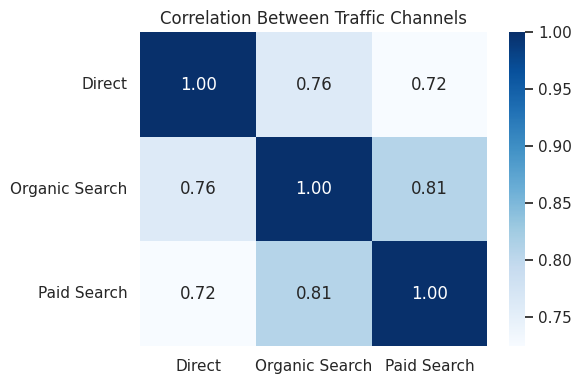

In [ ]:
# 7.3.1 VISUALIZATION: TRAFFIC CHANNEL CORRELATION MATRIX

plt.figure(figsize=(6, 4))

# Create heatmap
sns.heatmap(
    traffic_corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Traffic Channels")
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Pearson correlation and p-value for each pair of traffic channels

# Organic Search vs Paid Search
corr_org_paid, p_org_paid = pearsonr(
    traffic_sales_wide["Organic Search"],
    traffic_sales_wide["Paid Search"]
)

print("Organic Search vs Paid Search")
print(f"Correlation: {corr_org_paid:.4f}")
print(f"P-value: {p_org_paid:.6f}")
print("-" * 30)

# Organic Search vs Direct
corr_org_direct, p_org_direct = pearsonr(
    traffic_sales_wide["Organic Search"],
    traffic_sales_wide["Direct"]
)

print("Organic Search vs Direct")
print(f"Correlation: {corr_org_direct:.4f}")
print(f"P-value: {p_org_direct:.6f}")
print("-" * 30)

# Paid Search vs Direct
corr_paid_direct, p_paid_direct = pearsonr(
    traffic_sales_wide["Paid Search"],
    traffic_sales_wide["Direct"]
)

print("Paid Search vs Direct")
print(f"Correlation: {corr_paid_direct:.4f}")
print(f"P-value: {p_paid_direct:.6f}")

Organic Search vs Paid Search
Correlation: 0.8082
P-value: 0.000000
------------------------------
Organic Search vs Direct
Correlation: 0.7599
P-value: 0.000000
------------------------------
Paid Search vs Direct
Correlation: 0.7243
P-value: 0.000000


Sales from different traffic channels are strongly and positively correlated.

The strongest relationship is between Organic Search and Paid Search, suggesting that search-related traffic channels tend to grow or decline together.

In [ ]:
# 7.4 CORRELATION BETWEEN TOP 5 PRODUCT CATEGORIES

# Define top 5 product categories by sales
top5_categories = [
    "Sofas & armchairs",
    "Chairs",
    "Beds",
    "Bookcases & shelving units",
    "Cabinets & cupboards"
]

# Calculate daily sales by top product categories
category_daily_sales = (
    df[
        (df["product_category"].isin(top5_categories)) &
        (df["price"].notna())
    ]
    .groupby(["order_date", "product_category"], as_index=False)
    .agg(total_sales=("price", "sum"))
)

# Display first rows
category_daily_sales.head()

,order_date,product_category,total_sales
0,2020-11-01,Beds,14041.0
1,2020-11-01,Bookcases & shelving units,36701.0
2,2020-11-01,Cabinets & cupboards,13591.5
3,2020-11-01,Chairs,46006.0
4,2020-11-01,Sofas & armchairs,75216.0


In [ ]:
# Convert daily category sales to wide format
category_sales_wide = (
    category_daily_sales
    .pivot(
        index="order_date",
        columns="product_category",
        values="total_sales"
    )
)

# Display first rows
category_sales_wide.head()

product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
order_date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0


In [ ]:
# Calculate correlation matrix between product categories
category_corr = category_sales_wide.corr()

# Remove technical axis names to avoid labels with underscores on the heatmap
category_corr.index.name = None
category_corr.columns.name = None

# Display correlation matrix
category_corr

,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


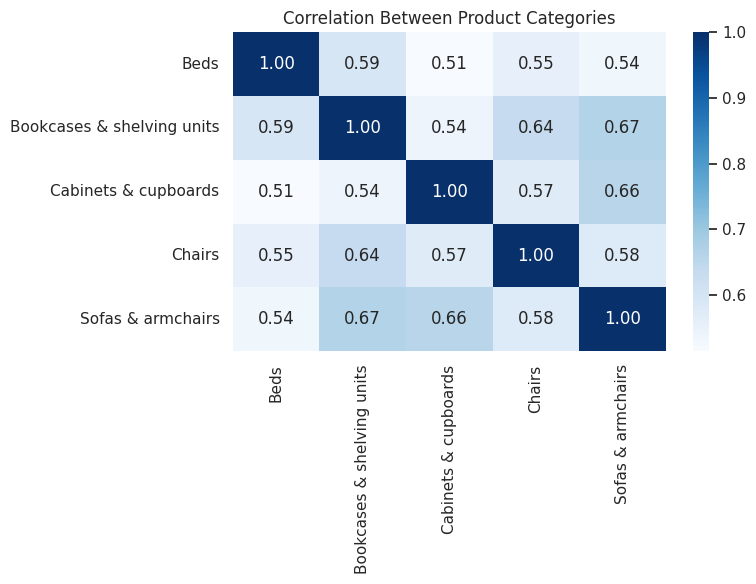

In [ ]:
# 7.4.1 VISUALIZATION: PRODUCT CATEGORY CORRELATION MATRIX

plt.figure(figsize=(8, 6))

# Create heatmap
sns.heatmap(
    category_corr,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Product Categories")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# 7.4.2 PEARSON CORRELATION FOR PRODUCT CATEGORY PAIRS

from itertools import combinations

# Get category names from wide table
categories = category_sales_wide.columns

# Calculate Pearson correlation and p-value for every category pair
for cat1, cat2 in combinations(categories, 2):
    corr, p = pearsonr(
        category_sales_wide[cat1],
        category_sales_wide[cat2]
    )

    print(f"{cat1} vs {cat2}")
    print(f"Correlation: {corr:.4f}")
    print(f"P-value: {p:.6f}")
    print("-" * 40)

Beds vs Bookcases & shelving units
Correlation: 0.5929
P-value: 0.000000
----------------------------------------
Beds vs Cabinets & cupboards
Correlation: 0.5146
P-value: 0.000000
----------------------------------------
Beds vs Chairs
Correlation: 0.5545
P-value: 0.000000
----------------------------------------
Beds vs Sofas & armchairs
Correlation: 0.5354
P-value: 0.000000
----------------------------------------
Bookcases & shelving units vs Cabinets & cupboards
Correlation: 0.5394
P-value: 0.000000
----------------------------------------
Bookcases & shelving units vs Chairs
Correlation: 0.6371
P-value: 0.000000
----------------------------------------
Bookcases & shelving units vs Sofas & armchairs
Correlation: 0.6662
P-value: 0.000000
----------------------------------------
Cabinets & cupboards vs Chairs
Correlation: 0.5729
P-value: 0.000000
----------------------------------------
Cabinets & cupboards vs Sofas & armchairs
Correlation: 0.6576
P-value: 0.000000
----------------

Top product categories show moderate positive correlations with each other.

All category pairs have statistically significant p-values, which suggests that sales of major product categories tend to increase and decrease together.

## 8. Statistical analysis of differences between groups

In this section, I compare different user and traffic groups using statistical tests.

Before selecting a test, I check whether samples follow a normal distribution using the Shapiro-Wilk test.

If the data is not normally distributed, I use non-parametric tests:
- Mann-Whitney U test for comparing two independent groups;
- Kruskal-Wallis test for comparing more than two independent groups;
- Z-test for proportions for comparing two shares.

In [ ]:
# 8.1 DAILY SALES BY REGISTRATION STATUS

# Calculate daily sales for registered users
daily_registered_sales = (
    df[df["account_id"].notna()]
    .groupby("order_date", as_index=False)
    .agg(total_sales=("price", "sum"))
)

# Calculate daily sales for unregistered users
daily_unregistered_sales = (
    df[df["account_id"].isna()]
    .groupby("order_date", as_index=False)
    .agg(total_sales=("price", "sum"))
)

# Display first rows for registered users
display(daily_registered_sales.head())

# Display first rows for unregistered users
display(daily_unregistered_sales.head())

,order_date,total_sales
0,2020-11-01,21547.0
1,2020-11-02,44956.8
2,2020-11-03,29150.5
3,2020-11-04,20982.2
4,2020-11-05,25334.6


,order_date,total_sales
0,2020-11-01,222745.5
1,2020-11-02,310550.0
2,2020-11-03,469829.1
3,2020-11-04,318204.9
4,2020-11-05,365942.0


In [ ]:
# Create samples for statistical comparison
registered_sample = daily_registered_sales["total_sales"]
unregistered_sample = daily_unregistered_sales["total_sales"]

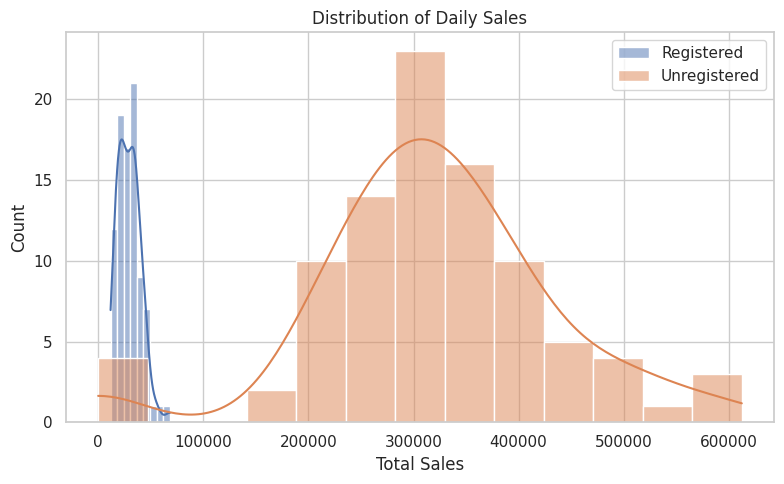

In [ ]:
# 8.1.1 VISUALIZATION: DISTRIBUTION OF DAILY SALES

plt.figure(figsize=(8, 5))

# Plot distribution for registered users
sns.histplot(
    registered_sample,
    kde=True,
    label="Registered",
    alpha=0.5
)

# Plot distribution for unregistered users
sns.histplot(
    unregistered_sample,
    kde=True,
    label="Unregistered",
    alpha=0.5
)

plt.legend()
plt.title("Distribution of Daily Sales")
plt.xlabel("Total Sales")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
# 8.1.2 NORMALITY CHECK: SHAPIRO-WILK TEST

# H0: the sample follows a normal distribution
# H1: the sample does not follow a normal distribution

shapiro_registered = shapiro(registered_sample)
shapiro_unregistered = shapiro(unregistered_sample)

print("Registered:", shapiro_registered)
print("Unregistered:", shapiro_unregistered)

Registered: ShapiroResult(statistic=np.float64(0.9591810175035426), pvalue=np.float64(0.007295139880540744))
Unregistered: ShapiroResult(statistic=np.float64(0.9487769113384333), pvalue=np.float64(0.0012184604855253293))


The Shapiro-Wilk test shows p-values below 0.05 for both samples.

This means that the null hypothesis of normal distribution should be rejected. Since the samples are not normally distributed, a non-parametric test is more appropriate for comparing these two groups.

In [ ]:
# 8.1.3 MANN-WHITNEY U TEST

from scipy.stats import mannwhitneyu

# H0: daily sales distributions are the same for registered and unregistered users
# H1: daily sales distributions are different between the two groups

u_stat, p_value = mannwhitneyu(
    registered_sample,
    unregistered_sample,
    alternative="two-sided"
)

print("U-statistic:", u_stat)
print("P-value:", p_value)

U-statistic: 352.0
P-value: 3.8805185465235906e-26


In [ ]:
# 8.2 Daily sessions by traffic channel

traffic_daily_sessions = (
    df.groupby(["order_date", "traffic_channel"])
      .agg(total_sessions=("ga_session_id", "nunique"))
      .reset_index()
)

traffic_daily_sessions.head()

,order_date,traffic_channel,total_sessions
0,2020-11-01,Direct,608
1,2020-11-01,Organic Search,920
2,2020-11-01,Paid Search,706
3,2020-11-01,Social Search,214
4,2020-11-01,Undefined,128


In [ ]:
# Create samples for top traffic channels
direct_sample = traffic_daily_sessions[
    traffic_daily_sessions["traffic_channel"] == "Direct"
]["total_sessions"]

organic_sample = traffic_daily_sessions[
    traffic_daily_sessions["traffic_channel"] == "Organic Search"
]["total_sessions"]

paid_sample = traffic_daily_sessions[
    traffic_daily_sessions["traffic_channel"] == "Paid Search"
]["total_sessions"]

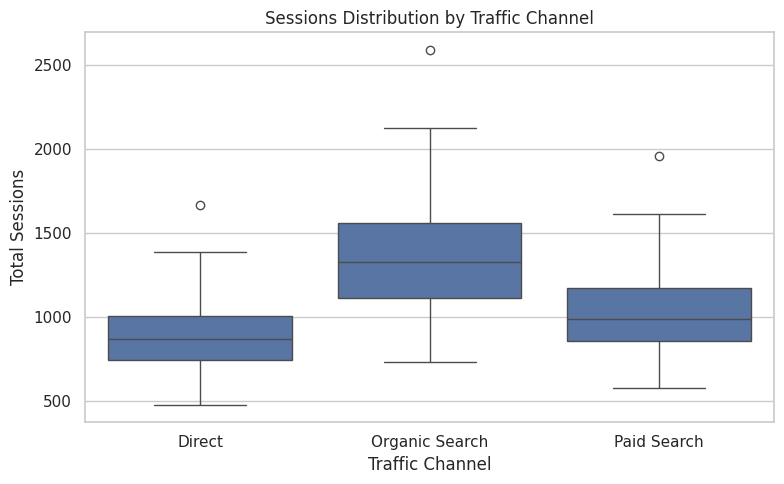

In [ ]:
# 8.2.1 VISUALIZATION: SESSIONS DISTRIBUTION BY TRAFFIC CHANNEL

plt.figure(figsize=(8, 5))

# Create boxplot for selected traffic channels
sns.boxplot(
    data=traffic_daily_sessions[
        traffic_daily_sessions["traffic_channel"].isin(
            ["Direct", "Organic Search", "Paid Search"]
        )
    ],
    x="traffic_channel",
    y="total_sessions"
)

plt.title("Sessions Distribution by Traffic Channel")
plt.xlabel("Traffic Channel")
plt.ylabel("Total Sessions")

plt.tight_layout()
plt.show()

In [ ]:
# 8.2.2 NORMALITY CHECK: SHAPIRO-WILK TEST

# H0: the sample follows a normal distribution
# H1: the sample does not follow a normal distribution

print("Direct:", shapiro(direct_sample))
print("Organic Search:", shapiro(organic_sample))
print("Paid Search:", shapiro(paid_sample))

Direct: ShapiroResult(statistic=np.float64(0.9703828213298022), pvalue=np.float64(0.034278771626201326))
Organic Search: ShapiroResult(statistic=np.float64(0.9640615387367748), pvalue=np.float64(0.012271774671209374))
Paid Search: ShapiroResult(statistic=np.float64(0.9632775096828393), pvalue=np.float64(0.010833125972481636))


The Shapiro-Wilk test returns p-values below 0.05 for all three traffic channel samples.

This indicates that the distributions are not normal. Since we compare more than two independent groups, the Kruskal-Wallis test is used.

In [ ]:
# 8.2.3 KRUSKAL-WALLIS TEST

from scipy.stats import kruskal

# H0: all traffic channels have the same distribution of daily sessions
# H1: at least one traffic channel differs from the others

stat, p_value = kruskal(
    direct_sample,
    organic_sample,
    paid_sample
)

print("Kruskal statistic:", stat)
print("P-value:", p_value)

Kruskal statistic: 96.32097258576631
P-value: 1.2138542891135678e-21


The Kruskal-Wallis test returns a p-value far below 0.05.

This means that there are statistically significant differences in the number of daily sessions between traffic channels.

In [ ]:
# 8.3 ORGANIC TRAFFIC SHARE IN AMERICAS AND EUROPE

# Calculate total sessions by continent
continent_sessions = (
    df.groupby("continent")
      .agg(total_sessions=("ga_session_id", "nunique"))
)

# Display sessions by continent
continent_sessions

,total_sessions
continent,
(not set),795
Africa,3620
Americas,193179
Asia,83113
Europe,65135
Oceania,3703


In [ ]:
# Calculate total sessions and organic sessions for Americas and Europe
comparison = (
    df[df["continent"].isin(["Americas", "Europe"])]
    .groupby("continent")
    .agg(
        total_sessions=("ga_session_id", "nunique"),
        organic_sessions=(
            "traffic_channel",
            lambda x: (x == "Organic Search").sum()
        )
    )
)

# Display comparison
comparison

,total_sessions,organic_sessions
continent,,
Americas,193179,68671
Europe,65135,23195


In [ ]:
# Calculate organic traffic share
comparison["organic_share"] = (
    comparison["organic_sessions"] /
    comparison["total_sessions"]
)

# Display organic share
comparison

,total_sessions,organic_sessions,organic_share
continent,,,
Americas,193179,68671,0.355479
Europe,65135,23195,0.356107


In [ ]:
# 8.3.1 Z-TEST FOR PROPORTIONS

from statsmodels.stats.proportion import proportions_ztest

# Number of organic sessions in each group
success = [
    comparison.loc["Americas", "organic_sessions"],
    comparison.loc["Europe", "organic_sessions"]
]

# Total number of sessions in each group
nobs = [
    comparison.loc["Americas", "total_sessions"],
    comparison.loc["Europe", "total_sessions"]
]

# H0: organic traffic share is the same in Americas and Europe
# H1: organic traffic share is different between Americas and Europe

z_stat, p_value = proportions_ztest(success, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -0.28951412926103953
P-value: 0.7721879690501752


The organic traffic share is almost the same in Americas and Europe: around 35.5% in both regions.

The z-test p-value is 0.77, which is higher than 0.05. Therefore, there is no statistically significant difference in organic traffic share between Americas and Europe.

## 9. Tableau dashboard dataset preparation

To build the Tableau dashboard, a lighter analytical dataset was created.

Only columns required for dashboard visualizations and filters were kept to reduce file size and improve Tableau performance.

Additional calculated fields were added to simplify dashboard creation.

In [ ]:
# 9. TABLEAU DASHBOARD DATASET

# Select only columns needed for Tableau dashboard
tableau_df = df[
    [
        "order_date",
        "ga_session_id",
        "continent",
        "country",
        "device",
        "traffic_channel",
        "account_id",
        "is_verified",
        "is_unsubscribed",
        "product_category",
        "price"
    ]
].copy()

# Add user type for easier dashboard filtering
tableau_df["user_type"] = np.where(
    tableau_df["account_id"].notna(),
    "Registered",
    "Unregistered"
)

# Add purchase flag for conversion-related analysis
tableau_df["has_purchase"] = np.where(
    tableau_df["price"].notna(),
    1,
    0
)

# Replace missing product category for sessions without purchase
tableau_df["product_category"] = tableau_df["product_category"].fillna(
    "No purchase"
)

# Export dataset for Tableau Public
tableau_df.to_csv(
    "tableau_dashboard_dataset.csv",
    index=False,
    encoding="utf-8"
)

# Display exported dataset preview
tableau_df.head()

,order_date,ga_session_id,continent,country,device,traffic_channel,account_id,is_verified,is_unsubscribed,product_category,price,user_type,has_purchase
0,2020-11-01,5760483956,Americas,United States,desktop,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,609.0,Unregistered,1
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,609.0,Unregistered,1
2,2020-11-01,3978035233,Europe,Norway,mobile,Direct,<NA>,<NA>,<NA>,Tables & desks,189.0,Unregistered,1
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,609.0,Unregistered,1
4,2020-11-01,4393441533,Asia,China,desktop,Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,609.0,Unregistered,1


In [ ]:
from google.colab import files
files.download("tableau_dashboard_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>